In [1]:
print('hello')

hello


In [2]:
import pandas as pd 
import numpy as np
import pickle


Carga de los datasets

In [3]:
datos = dict()
for i in range(1,7):
    nombre_archivo = f"../Simulaciones/sim_{i}_data.pkl"

    with open(nombre_archivo, 'rb') as f:
        datos_recuperados = pickle.load(f)
    datos[i]=datos_recuperados
    print(type(datos_recuperados),len(datos_recuperados))

<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20


Remuestreo

In [4]:
from Funciones import remuestrear
datos_prueba = {'t_min': list(range(1,16)),
    'valores': [0, 10, 0, 0, 20, 0, 0, 30, 0, 0, 0, 40, 0,1,3]
}
df_prueba = pd.DataFrame(datos_prueba)

print("DataFrame Original:")
print(df_prueba)

salida = remuestrear(df_prueba, ['t_min', 'valores'], 5)
print("\nDataFrame con los valores desplazados:")
print(salida)

DataFrame Original:
    t_min  valores
0       1        0
1       2       10
2       3        0
3       4        0
4       5       20
5       6        0
6       7        0
7       8       30
8       9        0
9      10        0
10     11        0
11     12       40
12     13        0
13     14        1
14     15        3

DataFrame con los valores desplazados:
    t_min  valores
0       6       10
5      30       50
10     55       40
15     29        4


In [5]:
datos.keys()

dict_keys([1, 2, 3, 4, 5, 6])

In [6]:
remuestrear(datos[3]['p_0'],columnas = ['meal_carb', 'snack_carb',
                                                     'bolus_insulin', 'basal_insulin'],
                                         t_muestreo=5)

,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0,6.000000,108.0,0.0,0.0,0.0,30.013287,0.0
5,5,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
10,10,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
15,15,5.999987,108.0,0.0,0.0,0.0,0.000000,0.0
20,20,5.999729,108.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...
43180,43180,9.728406,175.0,0.0,0.0,0.0,0.000000,0.0
43185,43185,9.669671,174.0,0.0,0.0,0.0,0.000000,0.0
43190,43190,9.610650,173.0,0.0,0.0,0.0,0.000000,0.0
43195,43195,9.551680,172.0,0.0,0.0,0.0,0.000000,0.0


In [16]:
for s in range(1,7):
    for p in range(20):
        print(f'p{p}')
        datos[s][f'p_{p}'] = remuestrear(datos[i][f'p_{p}'],
                                         columnas = ['meal_carb', 'snack_carb','bolus_insulin', 'basal_insulin'],
                                         t_muestreo=5)

p0
p1
p2
p3
p4
p5
p6
p7
p8
p9
p10
p11
p12
p13
p14
p15
p16
p17
p18
p19
p0
p1
p2
p3
p4
p5
p6
p7
p8
p9
p10
p11
p12
p13
p14
p15
p16
p17
p18
p19
p0
p1
p2
p3
p4
p5
p6
p7
p8
p9
p10
p11
p12
p13
p14
p15
p16
p17
p18
p19
p0
p1
p2
p3
p4
p5
p6
p7
p8
p9
p10
p11
p12
p13
p14
p15
p16
p17
p18
p19
p0
p1
p2
p3
p4
p5
p6
p7
p8
p9
p10
p11
p12
p13
p14
p15
p16
p17
p18
p19
p0
p1
p2
p3
p4
p5
p6
p7
p8
p9
p10
p11
p12
p13
p14
p15
p16
p17
p18
p19


Escalado y Estandarizado

In [7]:
from Funciones import escalar,estandarizar

display(datos[3]['p_0'].head())
display(escalar(datos[3]['p_0']).head())
estandarizar(datos[3]['p_0']).head()

,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0,6.0,108.0,0.0,0.0,0.0,30.013287,0.0
1,1,6.0,108.0,0.0,0.0,0.0,0.000000,0.0
2,2,6.0,108.0,0.0,0.0,0.0,0.000000,0.0
3,3,6.0,108.0,0.0,0.0,0.0,0.000000,0.0
4,4,6.0,108.0,0.0,0.0,0.0,0.000000,0.0


,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0,0.001242,0.0,0.0,0.0,0.0,1.0,0.0
1,1,0.001242,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0.001242,0.0,0.0,0.0,0.0,0.0,0.0
3,3,0.001242,0.0,0.0,0.0,0.0,0.0,0.0
4,4,0.001242,0.0,0.0,0.0,0.0,0.0,0.0


,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0,-3.932365,-3.932794,-0.044534,-0.03728,-0.044534,37.934153,-0.145131
1,1,-3.932365,-3.932794,-0.044534,-0.03728,-0.044534,-0.026361,-0.145131
2,2,-3.932365,-3.932794,-0.044534,-0.03728,-0.044534,-0.026361,-0.145131
3,3,-3.932365,-3.932794,-0.044534,-0.03728,-0.044534,-0.026361,-0.145131
4,4,-3.932365,-3.932794,-0.044534,-0.03728,-0.044534,-0.026361,-0.145131


In [8]:
datos[1]['p_0']['gluc_mg'].mean()

167.5513425925926

### Históricos

In [20]:
datos[1]['p_0'][datos[1]['p_0']['meal_carb']>0]

,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
503,503,5.993833,108.0,43.377778,0.0,1.845863,0.0,0.0
859,859,7.669420,138.0,75.530303,0.0,3.214055,0.0,0.0
1264,1264,8.367740,151.0,56.058586,0.0,2.385472,0.0,0.0
1961,1961,7.767855,140.0,46.088889,0.0,1.961229,0.0,0.0
2296,2296,9.092663,164.0,81.360606,0.0,3.462153,0.0,0.0
...,...,...,...,...,...,...,...,...
41190,41190,9.590798,173.0,76.396970,0.0,3.250935,0.0,0.0
41590,41590,9.513112,171.0,53.852525,0.0,2.291597,0.0,0.0
42285,42285,8.559010,154.0,44.488889,0.0,1.893144,0.0,0.0
42635,42635,9.523104,171.0,79.312121,0.0,3.374984,0.0,0.0


In [21]:
df_prueba = remuestrear(datos[1]['p_0'], columnas = ['meal_carb', 'snack_carb','bolus_insulin', 'basal_insulin'], t_muestreo=5)

In [22]:
display(df_prueba.head())
df_prueba = df_prueba.drop('glu_mmol', axis=1)
df_prueba.head()

,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0,6.000000,108.0,0.0,0.0,0.0,30.013287,0.0
5,5,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
10,10,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
15,15,5.999987,108.0,0.0,0.0,0.0,0.000000,0.0
20,20,5.999729,108.0,0.0,0.0,0.0,0.000000,0.0


,t_min,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0,108.0,0.0,0.0,0.0,30.013287,0.0
5,5,108.0,0.0,0.0,0.0,0.000000,0.0
10,10,108.0,0.0,0.0,0.0,0.000000,0.0
15,15,108.0,0.0,0.0,0.0,0.000000,0.0
20,20,108.0,0.0,0.0,0.0,0.000000,0.0


In [23]:
df_prueba.columns

Index(['t_min', 'gluc_mg', 'meal_carb', 'snack_carb', 'bolus_insulin',
       'basal_insulin', 'running_speed'],
      dtype='object')

In [27]:
df_prueba['gluc_lag_1'] = df_prueba['gluc_mg'].shift(1)
df_prueba['gluc_lag_2'] = df_prueba['gluc_mg'].shift(2)
df_prueba['gluc_lag_3'] = df_prueba['gluc_mg'].shift(3)
df_prueba['basal_-24h'] = df_prueba['basal_insulin'].rolling(window=287, closed='left').sum()

for col in ['gluc_mg', 'meal_carb', 'snack_carb', 'bolus_insulin', 'running_speed']:

    df_prueba[f'{col}_-20m'] = df_prueba[col].rolling(window=4, closed='left').sum()
    df_prueba[f'{col}_-40m'] = df_prueba[col].rolling(window=8, closed='left').sum() - df_prueba[col].rolling(window=4, closed='left').sum()
    df_prueba[f'{col}_-60m'] = df_prueba[col].rolling(window=12, closed='left').sum() - df_prueba[col].rolling(window=8, closed='left').sum()
    df_prueba[f'{col}_-80m'] = df_prueba[col].rolling(window=16, closed='left').sum() - df_prueba[col].rolling(window=12, closed='left').sum()
    df_prueba[f'{col}_-100m'] = df_prueba[col].rolling(window=20, closed='left').sum() - df_prueba[col].rolling(window=16, closed='left').sum()
    df_prueba[f'{col}_-120m'] = df_prueba[col].rolling(window=24, closed='left').sum() - df_prueba[col].rolling(window=20, closed='left').sum()
    df_prueba[f'{col}_-140m'] = df_prueba[col].rolling(window=28, closed='left').sum() - df_prueba[col].rolling(window=24, closed='left').sum()
    df_prueba[f'{col}_-160m'] = df_prueba[col].rolling(window=32, closed='left').sum() - df_prueba[col].rolling(window=28, closed='left').sum()
    df_prueba[f'{col}_-180m'] = df_prueba[col].rolling(window=36, closed='left').sum() - df_prueba[col].rolling(window=32, closed='left').sum()
    df_prueba[f'{col}_-200m'] = df_prueba[col].rolling(window=40, closed='left').sum() - df_prueba[col].rolling(window=36, closed='left').sum()
    df_prueba[f'{col}_-220m'] = df_prueba[col].rolling(window=44, closed='left').sum() - df_prueba[col].rolling(window=40, closed='left').sum()
    df_prueba[f'{col}_-240m'] = df_prueba[col].rolling(window=48, closed='left').sum() - df_prueba[col].rolling(window=44, closed='left').sum()

df_prueba.loc[1435:,:].head(50)


,t_min,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed,gluc_lag_1,gluc_lag_2,gluc_lag_3,...,running_speed_-80m,running_speed_-100m,running_speed_-120m,running_speed_-140m,running_speed_-160m,running_speed_-180m,running_speed_-200m,running_speed_-220m,running_speed_-240m,basal_-24h
1435,1435,164.0,0.0,0.0,0.0,0.000000,0.0,165.0,166.0,167.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
1440,1440,163.0,0.0,0.0,0.0,30.013287,0.0,164.0,165.0,166.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1445,1445,162.0,0.0,0.0,0.0,0.000000,0.0,163.0,164.0,165.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
1450,1450,161.0,0.0,0.0,0.0,0.000000,0.0,162.0,163.0,164.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
1455,1455,160.0,0.0,0.0,0.0,0.000000,0.0,161.0,162.0,163.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
1460,1460,159.0,0.0,0.0,0.0,0.000000,0.0,160.0,161.0,162.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
1465,1465,158.0,0.0,0.0,0.0,0.000000,0.0,159.0,160.0,161.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
1470,1470,157.0,0.0,0.0,0.0,0.000000,0.0,158.0,159.0,160.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
1475,1475,156.0,0.0,0.0,0.0,0.000000,0.0,157.0,158.0,159.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
1480,1480,155.0,0.0,0.0,0.0,0.000000,0.0,156.0,157.0,158.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287


In [43]:
from skforecast.direct import ForecasterDirect
from xgboost import XGBRegressor

34560
x_cols = ['meal_carb', 'snack_carb', 'bolus_insulin',
       'basal_insulin', 'running_speed', 'gluc_lag_1', 'gluc_lag_2',
       'gluc_lag_3', 'gluc_mg_-20m', 'gluc_mg_-40m', 'gluc_mg_-60m',
       'gluc_mg_-80m', 'gluc_mg_-100m', 'gluc_mg_-120m', 'gluc_mg_-140m',
       'gluc_mg_-160m', 'gluc_mg_-180m', 'gluc_mg_-200m', 'gluc_mg_-220m',
       'gluc_mg_-240m', 'meal_carb_-20m', 'meal_carb_-40m', 'meal_carb_-60m',
       'meal_carb_-80m', 'meal_carb_-100m', 'meal_carb_-120m',
       'meal_carb_-140m', 'meal_carb_-160m', 'meal_carb_-180m',
       'meal_carb_-200m', 'meal_carb_-220m', 'meal_carb_-240m',
       'snack_carb_-20m', 'snack_carb_-40m', 'snack_carb_-60m',
       'snack_carb_-80m', 'snack_carb_-100m', 'snack_carb_-120m',
       'snack_carb_-140m', 'snack_carb_-160m', 'snack_carb_-180m',
       'snack_carb_-200m', 'snack_carb_-220m', 'snack_carb_-240m',
       'bolus_insulin_-20m', 'bolus_insulin_-40m', 'bolus_insulin_-60m',
       'bolus_insulin_-80m', 'bolus_insulin_-100m', 'bolus_insulin_-120m',
       'bolus_insulin_-140m', 'bolus_insulin_-160m', 'bolus_insulin_-180m',
       'bolus_insulin_-200m', 'bolus_insulin_-220m', 'bolus_insulin_-240m',
       'running_speed_-20m', 'running_speed_-40m', 'running_speed_-60m',
       'running_speed_-80m', 'running_speed_-100m', 'running_speed_-120m',
       'running_speed_-140m', 'running_speed_-160m', 'running_speed_-180m',
       'running_speed_-200m', 'running_speed_-220m', 'running_speed_-240m',
       'basal_-24h']

x_train = df_prueba.loc[:34560, x_cols]
x_test = df_prueba.loc[34560:, x_cols]

y_train = df_prueba.loc[:34560, 'gluc_mg']
y_test = df_prueba.loc[34560:, 'gluc_mg']

display(x_train.head())
display(x_test.head())
display(y_train.head())
display(y_test.head())

,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed,gluc_lag_1,gluc_lag_2,gluc_lag_3,gluc_mg_-20m,gluc_mg_-40m,...,running_speed_-80m,running_speed_-100m,running_speed_-120m,running_speed_-140m,running_speed_-160m,running_speed_-180m,running_speed_-200m,running_speed_-220m,running_speed_-240m,basal_-24h
0,0.0,0.0,0.0,30.013287,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.0,0.0,0.0,0.000000,0.0,108.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,0.0,0.0,0.0,0.000000,0.0,108.0,108.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,0.0,0.0,0.0,0.000000,0.0,108.0,108.0,108.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,0.0,0.0,0.0,0.000000,0.0,108.0,108.0,108.0,432.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed,gluc_lag_1,gluc_lag_2,gluc_lag_3,gluc_mg_-20m,gluc_mg_-40m,...,running_speed_-80m,running_speed_-100m,running_speed_-120m,running_speed_-140m,running_speed_-160m,running_speed_-180m,running_speed_-200m,running_speed_-220m,running_speed_-240m,basal_-24h
34560,0.0,0.0,0.0,30.013287,0.0,174.0,175.0,176.0,702.0,718.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
34565,0.0,0.0,0.0,0.000000,0.0,173.0,174.0,175.0,698.0,714.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
34570,0.0,0.0,0.0,0.000000,0.0,172.0,173.0,174.0,694.0,710.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
34575,0.0,0.0,0.0,0.000000,0.0,171.0,172.0,173.0,690.0,706.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
34580,0.0,0.0,0.0,0.000000,0.0,170.0,171.0,172.0,686.0,702.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287


0     108.0
5     108.0
10    108.0
15    108.0
20    108.0
Name: gluc_mg, dtype: float64

34560    173.0
34565    172.0
34570    171.0
34575    170.0
34580    169.0
Name: gluc_mg, dtype: float64

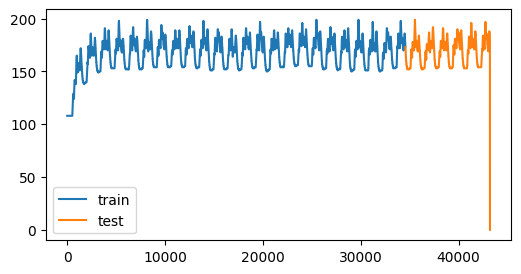

In [44]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3))
y_train.plot(ax=ax, label='train')
y_test.plot(ax=ax, label='test')
ax.legend()

In [45]:
forecaster = ForecasterDirect(
                 estimator       = XGBRegressor(),
                 steps           = 4,
                 )
forecaster.fit(y=y_train,exog=x_train)
forecaster

ValueError: At least one of the arguments `lags` or `window_features` must be different from None. This is required to create the predictors used in training the forecaster.

### Estadíticas

In [9]:
from Funciones import estadisticas_rango

estadisticas_rango(datos[1]['p_2'])


{'TIR': [28.31], 'TAR': [71.69], 'TBR': [0.0]}

In [10]:
estadisticas = pd.DataFrame(columns=['Simulacion','Paciente', 'TBR', 'TIR', 'TAR'])
# display(est)
for simu in range(1,7):
    for p in range(20):
        est_l = estadisticas_rango(datos[simu][f'p_{p}'])
        est_l.update({'Simulacion': [simu], 'Paciente': [p]})
        df_l = pd.DataFrame(est_l)
        estadisticas = pd.concat([estadisticas, df_l])
estadisticas.head(20)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15204\966208211.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  estadisticas = pd.concat([estadisticas, df_l])


,Simulacion,Paciente,TBR,TIR,TAR
0,1,0,0.0,83.94,16.06
0,1,1,0.0,98.83,1.17
0,1,2,0.0,28.31,71.69
0,1,3,0.0,25.56,74.44
0,1,4,0.0,1.65,98.35
0,1,5,0.0,100.00,0.00
0,1,6,0.0,92.22,7.78
0,1,7,0.0,99.96,0.04
0,1,8,0.0,3.47,96.53
0,1,9,0.0,1.95,98.05


In [13]:
for i in range(20):
    display(estadisticas[estadisticas['Paciente']==i])

,Simulacion,Paciente,TBR,TIR,TAR
0,1,0,0.0,83.94,16.06
0,2,0,0.0,82.77,17.23
0,3,0,0.0,95.70,4.30
0,4,0,0.0,79.35,20.65
0,5,0,0.0,84.66,15.34
0,6,0,0.0,87.15,12.85


,Simulacion,Paciente,TBR,TIR,TAR
0,1,1,0.0,98.83,1.17
0,2,1,0.0,98.41,1.59
0,3,1,0.0,99.57,0.43
0,4,1,0.0,93.62,6.38
0,5,1,0.0,98.16,1.84
0,6,1,0.0,98.08,1.92


,Simulacion,Paciente,TBR,TIR,TAR
0,1,2,0.0,28.31,71.69
0,2,2,0.0,29.02,70.98
0,3,2,0.0,29.50,70.50
0,4,2,0.0,30.22,69.78
0,5,2,0.0,27.14,72.86
0,6,2,0.0,29.57,70.43


,Simulacion,Paciente,TBR,TIR,TAR
0,1,3,0.0,25.56,74.44
0,2,3,0.0,22.05,77.95
0,3,3,0.0,30.52,69.48
0,4,3,0.0,14.76,85.24
0,5,3,0.0,17.80,82.20
0,6,3,0.0,24.45,75.55


,Simulacion,Paciente,TBR,TIR,TAR
0,1,4,0.0,1.65,98.35
0,2,4,0.0,2.25,97.75
0,3,4,0.0,2.19,97.81
0,4,4,0.0,6.81,93.19
0,5,4,0.0,4.71,95.29
0,6,4,0.0,4.96,95.04


...

,Simulacion,Paciente,TBR,TIR,TAR
0,1,15,0.0,2.04,97.96
0,2,15,0.0,2.55,97.45
0,3,15,0.0,2.45,97.55
0,4,15,0.0,3.63,96.37
0,5,15,0.0,3.16,96.84
0,6,15,0.0,3.80,96.20


,Simulacion,Paciente,TBR,TIR,TAR
0,1,16,0.0,11.28,88.72
0,2,16,0.0,11.60,88.40
0,3,16,0.0,16.61,83.39
0,4,16,0.0,11.81,88.19
0,5,16,0.0,10.98,89.02
0,6,16,0.0,13.31,86.69


,Simulacion,Paciente,TBR,TIR,TAR
0,1,17,0.0,75.79,24.21
0,2,17,0.0,73.70,26.30
0,3,17,0.0,77.36,22.64
0,4,17,0.0,68.87,31.13
0,5,17,0.0,71.57,28.43
0,6,17,0.0,74.62,25.38


,Simulacion,Paciente,TBR,TIR,TAR
0,1,18,0.0,92.35,7.65
0,2,18,0.0,91.09,8.91
0,3,18,0.0,92.83,7.17
0,4,18,0.0,90.19,9.81
0,5,18,0.0,89.29,10.71
0,6,18,0.0,89.77,10.23


,Simulacion,Paciente,TBR,TIR,TAR
0,1,19,0.0,22.86,77.14
0,2,19,0.0,22.88,77.12
0,3,19,0.0,39.56,60.44
0,4,19,0.0,25.83,74.17
0,5,19,0.0,24.02,75.98
0,6,19,0.0,35.03,64.97
